In [6]:
! [ -e /content ] && pip install -Uqq fastbook
import fastbook
fastbook.setup_book()
from fastai.vision.all import *
from fastbook import *

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 719.8/719.8 kB 3.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.1/124.1 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 246.9/246.9 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 19.7 MB/s eta 0:00:0000:0100:01


kernel for our model

In [7]:
top_edge = tensor([[-1,-1,-1],
                   [ 0, 0, 0],
                   [ 1, 1, 1]]).float()

Loading the image

In [8]:
path = untar_data(URLs.MNIST_SAMPLE)
path

<div><progress max="3214948" value="3219456"></progress> 100.14% [3219456/3214948 00:01&lt;00:00]</div>

Path('/root/.fastai/data/mnist_sample')

<Axes: >

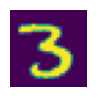

In [9]:
img = Image.open(path/'train'/'3'/'12.png')
show_image(img)

Multiplication of top 3*3 pixel of image with the kernel

In [15]:
tensor_img = tensor(img)  #converting the image into tensor
output = (tensor_img[0:3 , 0:3] * top_edge).sum()
output

tensor(0.)

As we can observe from the above result that, all the pixels in the top left corner are white.

Coloring the cell of a dataframe based on the numerical value inside the cell.

In [16]:
df = pd.DataFrame(tensor_img[:10,:20])
df.style.set_properties(**{'font-size':'6pt'}).background_gradient('Greys')

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,0,0,0,12,99,91,142,155,246,182,155,155,155,155,131,52,0,0,0,0
6,0,0,0,138,254,254,254,254,254,254,254,254,254,254,254,252,210,122,33,0
7,0,0,0,220,254,254,254,235,189,189,189,189,150,189,205,254,254,254,75,0
8,0,0,0,35,74,35,35,25,0,0,0,0,0,0,13,224,254,254,153,0
9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,90,254,254,247,53,0


Top edge

In [20]:
output_1 = (tensor_img[4:7 , 6:9] * top_edge).sum()
output_1

tensor(762.)

Right edge corner

In [21]:
output_2 = (tensor_img[7:10 , 17:20] * top_edge).sum()
output_2

tensor(-29.)

Function to multiply matrix with the filter


In [24]:
def apply_filter(row, col, kernel):
    #making 3 * 3 matrix from given index of row and column
    return (tensor_img[row - 1:row + 2 , col - 1: col + 2] * kernel).sum()
apply_filter(5,7,top_edge)    

tensor(762.)

Example of coordinate grid

In [25]:
[[(i,j) for j in range(1,5)] for i in range(1,5)]

[[(1, 1), (1, 2), (1, 3), (1, 4)],
 [(2, 1), (2, 2), (2, 3), (2, 4)],
 [(3, 1), (3, 2), (3, 3), (3, 4)],
 [(4, 1), (4, 2), (4, 3), (4, 4)]]

<Axes: >

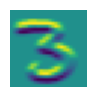

In [27]:
top_3 = [[apply_filter(i,j,top_edge) for j in range(1,27)] for i in range(1,27)]
show_image(top_3)